# Clustering analysis

Inspect, transform, scale and cluster the saved daily dataset.

Run from the repository folder with the `.venv` kernel. This notebook uses local data only; run `01_daily_macro_dataset.ipynb` first if the CSV is missing.


In [336]:
import numpy as np
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


## Load and preview

Load the version that preserves all equity trading dates and missing macro observations. No filling or scaling is applied.


In [337]:
df = pd.read_csv("data/daily_macro_levels.csv", index_col="date", parse_dates=["date"])
df.head()


,sp500,breakeven_10y,real_yield_10y,slope_10y_2y,baa_10y_spread,vix,vix3m,vix_term_spread,sp500_gold_ratio
date,,,,,,,,,
2011-10-05,1144.030029,1.80,0.12,1.67,3.36,37.81,38.31,-0.50,0.697452
2011-10-06,1164.969971,1.88,0.13,1.72,3.34,36.27,37.04,-0.77,0.705230
2011-10-07,1155.459961,1.94,0.16,1.80,3.32,36.20,37.31,-1.11,0.706920
2011-10-10,1194.890015,NaN,NaN,NaN,NaN,33.02,34.79,-1.77,0.715674
2011-10-11,1195.540039,1.95,0.23,1.86,3.32,32.86,34.06,-1.20,0.720335


In [338]:
df.isnull().sum()

sp500                0
breakeven_10y       28
real_yield_10y      28
slope_10y_2y        28
baa_10y_spread      30
vix                  0
vix3m                0
vix_term_spread      0
sp500_gold_ratio     3
dtype: int64

In [339]:
df_complete = df.dropna()
df_complete.isnull().sum()

sp500               0
breakeven_10y       0
real_yield_10y      0
slope_10y_2y        0
baa_10y_spread      0
vix                 0
vix3m               0
vix_term_spread     0
sp500_gold_ratio    0
dtype: int64

## Daily levels: compact mosaic

One time-series panel per variable, with a shared date axis and separate vertical scales. Use the complete observations in `df_complete`. The term spread is **VIX − VIX3M**.

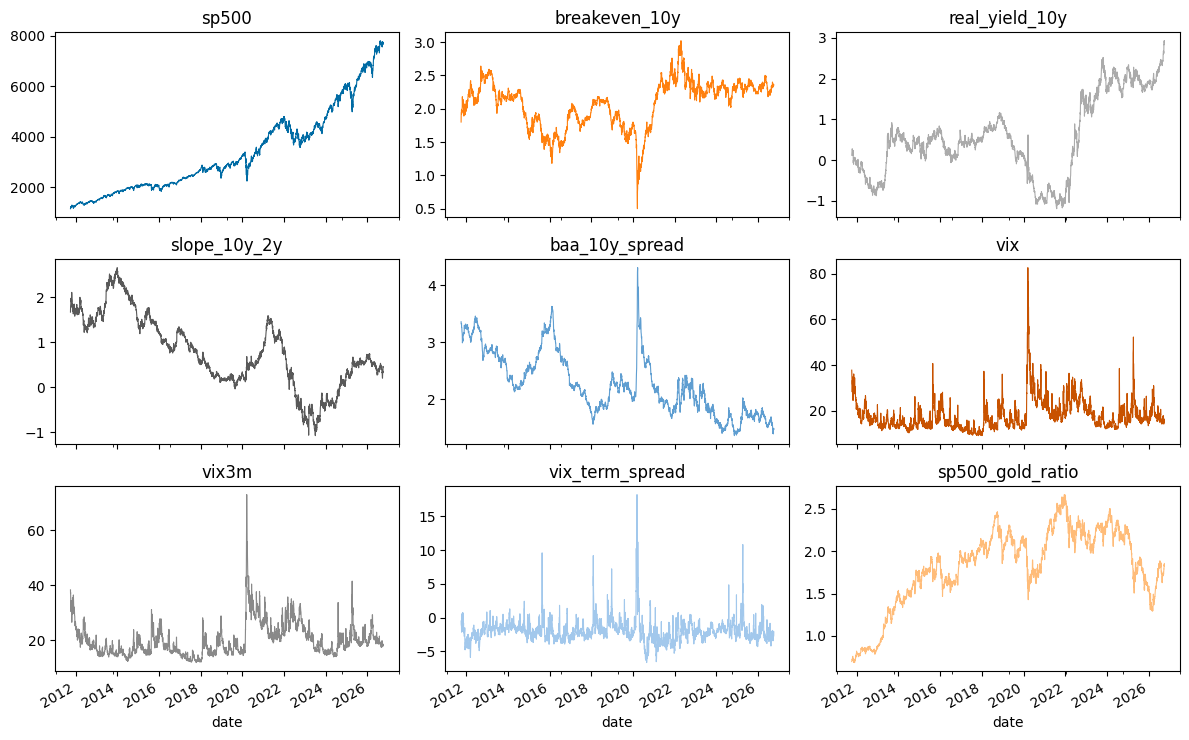

In [340]:
plot_rows = (len(df_complete.columns) + 2) // 3
with plt.style.context("tableau-colorblind10"):
    axes = df_complete.plot(subplots=True, layout=(plot_rows, 3), figsize=(12, 2.5 * plot_rows),
                   sharex=True, legend=False, linewidth=0.8)
    for ax, column in zip(axes.flat, df_complete.columns):
        ax.set_title(column)
    for ax in axes.flat[len(df_complete.columns):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

## S&P 500 log returns

Chapter 3.2.1 uses previously calculated equity log returns. Here we calculate them from our S&P 500 levels; the other variables remain in levels. Calculate returns on `df` before dropping missing rows to preserve the equity trading-day intervals.

The precomputed `sp500_gold_ratio` is loaded from the builder and remains in levels. It passes through `StandardScaler` with every other feature before PCA, t-SNE and clustering. Gold prices are only a source input in the builder and are not exported as a separate feature.


In [341]:
df_transformed = df.copy()
df_transformed["sp500"] = np.log(df["sp500"]).diff()
df_transformed = df_transformed.rename(columns={"sp500": "sp500_log_return"}).dropna()
df_transformed.head()


,sp500_log_return,breakeven_10y,real_yield_10y,slope_10y_2y,baa_10y_spread,vix,vix3m,vix_term_spread,sp500_gold_ratio
date,,,,,,,,,
2011-10-06,0.018138,1.88,0.13,1.72,3.34,36.27,37.04,-0.77,0.705230
2011-10-07,-0.008197,1.94,0.16,1.80,3.32,36.20,37.31,-1.11,0.706920
2011-10-11,0.000544,1.95,0.23,1.86,3.32,32.86,34.06,-1.20,0.720335
2011-10-12,0.009747,1.98,0.26,1.95,3.33,31.26,32.97,-1.71,0.718046
2011-10-13,-0.002978,1.92,0.27,1.90,3.29,30.70,32.71,-2.01,0.721922


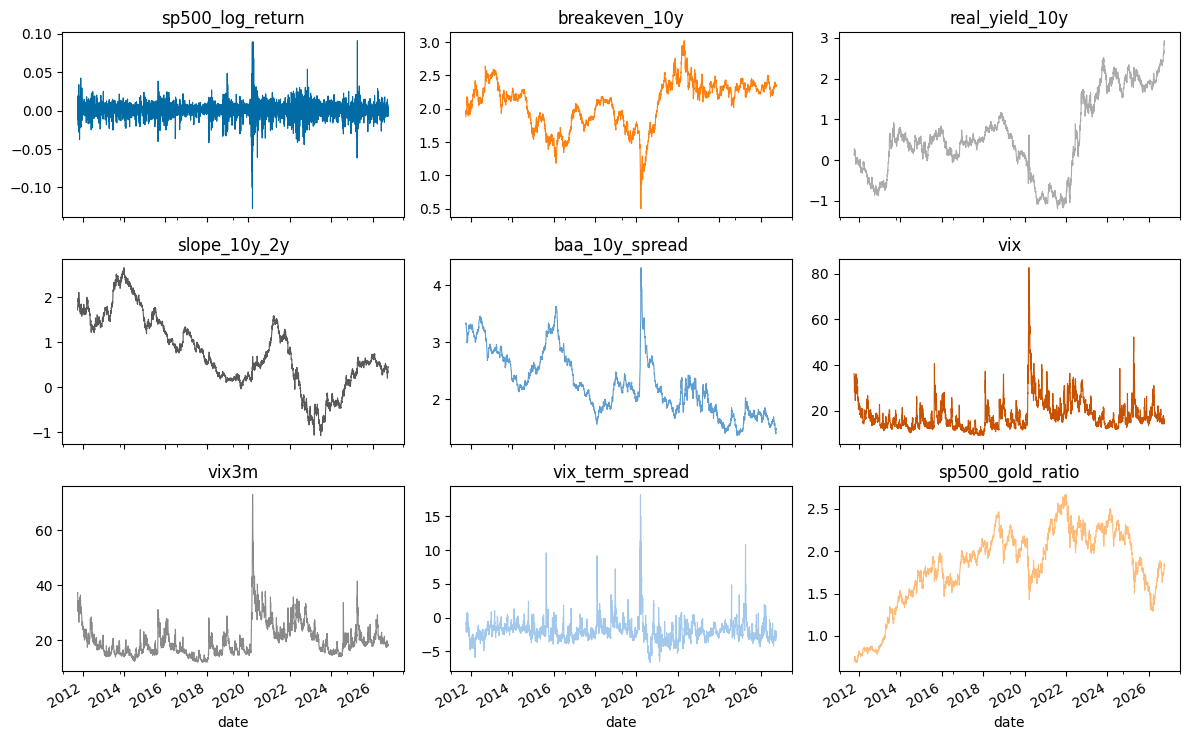

In [342]:
plot_rows = (len(df_transformed.columns) + 2) // 3
with plt.style.context("tableau-colorblind10"):
    axes = df_transformed.plot(subplots=True, layout=(plot_rows, 3), figsize=(12, 2.5 * plot_rows),
                               sharex=True, legend=False, linewidth=0.8)
    for ax, column in zip(axes.flat, df_transformed.columns):
        ax.set_title(column)
    for ax in axes.flat[len(df_transformed.columns):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

## Clustering

To be developed next: choose features and transformations, then fit and evaluate clusters.


In [343]:
df_transformed = df.copy()
df_transformed["sp500"] = np.log(df["sp500"]).diff()
df_transformed = df_transformed.rename(columns={"sp500": "sp500_log_return"}).dropna()
df_transformed.head()


,sp500_log_return,breakeven_10y,real_yield_10y,slope_10y_2y,baa_10y_spread,vix,vix3m,vix_term_spread,sp500_gold_ratio
date,,,,,,,,,
2011-10-06,0.018138,1.88,0.13,1.72,3.34,36.27,37.04,-0.77,0.705230
2011-10-07,-0.008197,1.94,0.16,1.80,3.32,36.20,37.31,-1.11,0.706920
2011-10-11,0.000544,1.95,0.23,1.86,3.32,32.86,34.06,-1.20,0.720335
2011-10-12,0.009747,1.98,0.26,1.95,3.33,31.26,32.97,-1.71,0.718046
2011-10-13,-0.002978,1.92,0.27,1.90,3.29,30.70,32.71,-2.01,0.721922


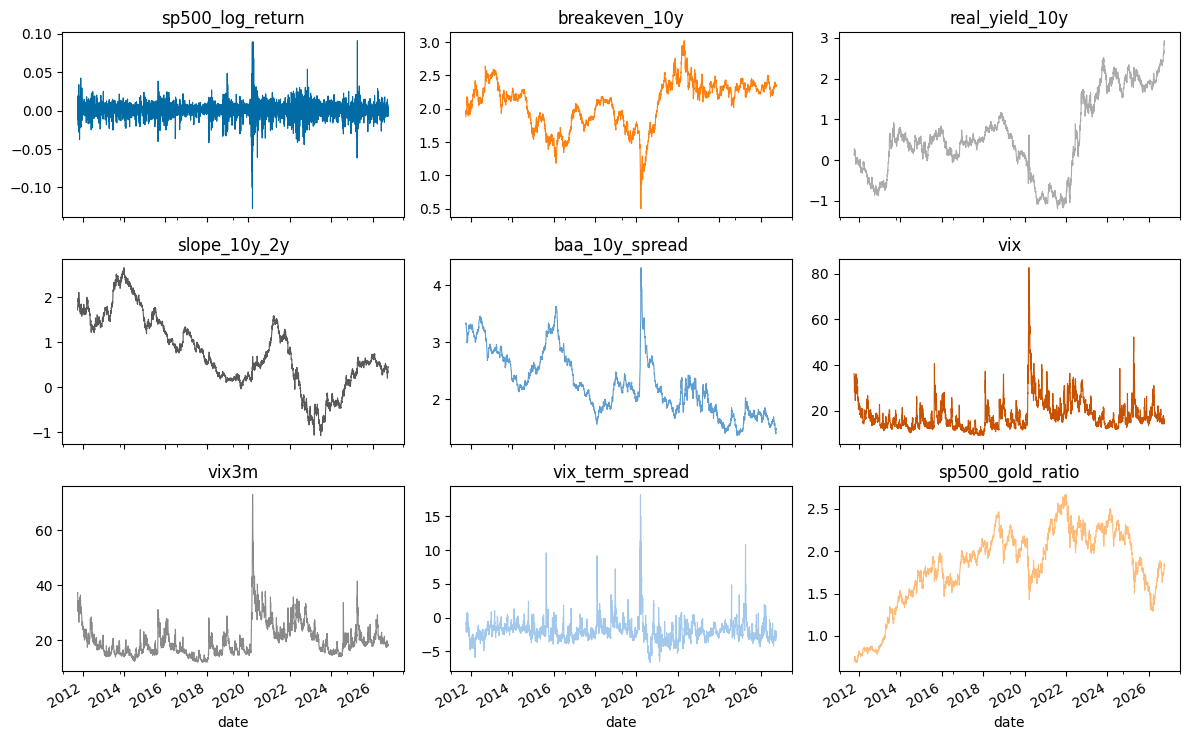

In [344]:
plot_rows = (len(df_transformed.columns) + 2) // 3
with plt.style.context("tableau-colorblind10"):
    axes = df_transformed.plot(subplots=True, layout=(plot_rows, 3), figsize=(12, 2.5 * plot_rows),
                               sharex=True, legend=False, linewidth=0.8)
    for ax, column in zip(axes.flat, df_transformed.columns):
        ax.set_title(column)
    for ax in axes.flat[len(df_transformed.columns):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

## Conventional partitioning

This plot shows a potential partitioning of the market variables with a 25-75 percentile low-mid-high logic. 

This can offer intuitive interpretability certain cases. A major risk is that the joint occurrance of certian states get too low, sparse. In this current configuration there are 3^9 = 19,683 joint states. It is almost impossible to understand all those scenarios. Instead, I propose unsupervised technique to compress the states down to smaller number with distinguishable profiles. 

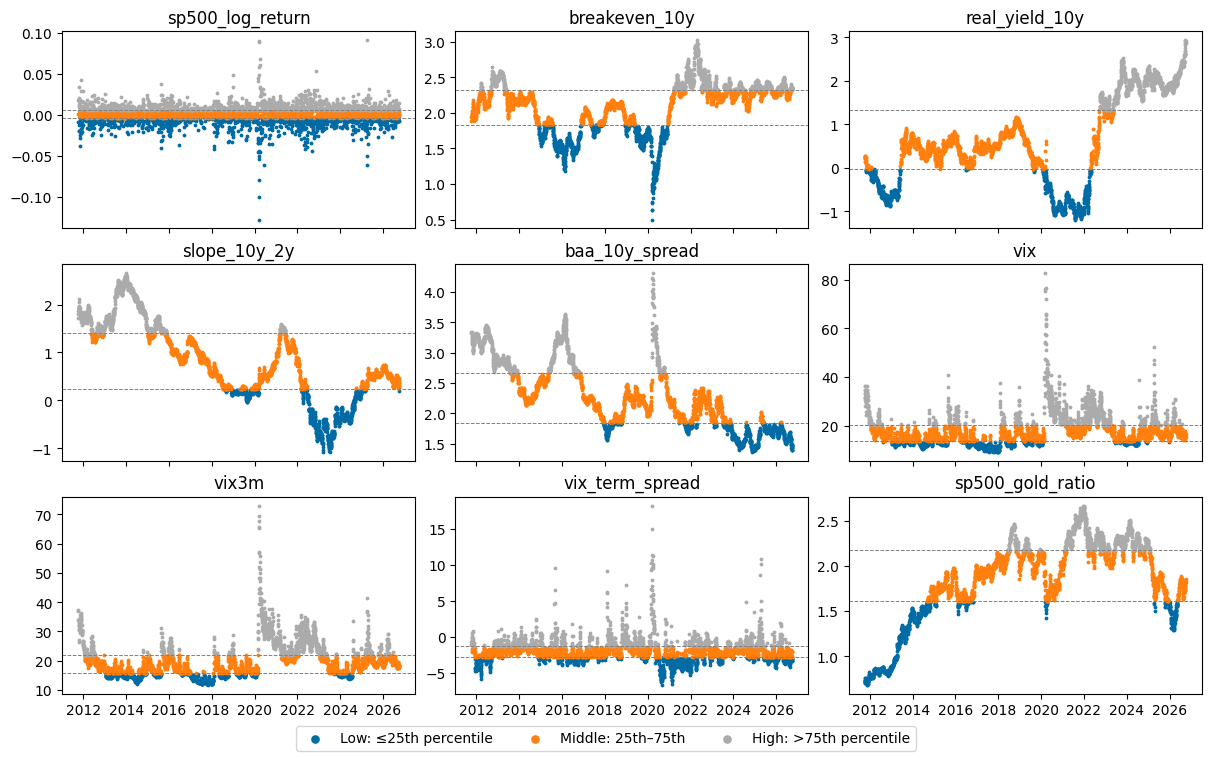

In [345]:
plot_rows = (len(df_transformed.columns) + 2) // 3
with plt.style.context("tableau-colorblind10"):
    fig, axes = plt.subplots(plot_rows, 3, figsize=(12, 2.5 * plot_rows), sharex=True, layout="constrained")
    for ax, column in zip(axes.flat, df_transformed.columns):
        series = df_transformed[column]
        q25, q75 = series.quantile([0.25, 0.75])
        partitions = {
            "Low: ≤25th percentile": series <= q25,
            "Middle: 25th–75th": (series > q25) & (series <= q75),
            "High: >75th percentile": series > q75,
        }
        for label, mask in partitions.items():
            ax.scatter(series.index[mask], series[mask], s=3, label=label)
        for threshold in [q25, q75]:
            ax.axhline(threshold, color="grey", linestyle="--", linewidth=0.7)
        ax.set_title(column)

    for ax in axes.flat[len(df_transformed.columns):]:
        ax.set_visible(False)
    fig.legend(*axes.flat[0].get_legend_handles_labels(),
               loc="outside lower center", ncol=3, markerscale=3)
    plt.show()

## EDA

In [346]:
df_transformed.describe(include = 'all').T

,count,mean,std,min,25%,50%,75%,max
sp500_log_return,3738.0,0.000496,0.010610,-0.127652,-0.003764,0.000671,0.005640,0.090895
breakeven_10y,3738.0,2.073093,0.348344,0.500000,1.830000,2.160000,2.320000,3.020000
real_yield_10y,3738.0,0.571683,0.960495,-1.190000,-0.027500,0.480000,1.320000,2.930000
slope_10y_2y,3738.0,0.781870,0.808628,-1.080000,0.230000,0.670000,1.410000,2.660000
baa_10y_spread,3738.0,2.274955,0.540683,1.360000,1.840000,2.200000,2.670000,4.310000
vix,3738.0,17.911715,6.588350,9.140000,13.590000,16.270000,20.337500,82.690000
vix3m,3738.0,19.870626,5.892105,11.850000,15.700000,18.480000,22.010000,72.980000
vix_term_spread,3738.0,-1.958911,1.658359,-6.660000,-2.840000,-2.110000,-1.310000,18.230000
sp500_gold_ratio,3738.0,1.823214,0.456171,0.685139,1.606641,1.894439,2.172356,2.669226


In [347]:
from sklearn.preprocessing import StandardScaler
# Scaling the data before clustering
scaler = StandardScaler()
subset = df_transformed.copy()
subset_scaled = scaler.fit_transform(subset)

In [348]:
subset_scaled_df = pd.DataFrame(
    subset_scaled, columns=subset.columns, index=subset.index
)

In [349]:
subset_scaled_df.head()

,sp500_log_return,breakeven_10y,real_yield_10y,slope_10y_2y,baa_10y_spread,vix,vix3m,vix_term_spread,sp500_gold_ratio
date,,,,,,,,,
2011-10-06,1.663041,-0.554390,-0.459911,1.160306,1.970079,2.786850,2.914352,0.717016,-2.451125
2011-10-07,-0.819426,-0.382123,-0.428673,1.259253,1.933083,2.776223,2.960183,0.511967,-2.447422
2011-10-11,0.004513,-0.353412,-0.355784,1.333462,1.933083,2.269200,2.408523,0.457689,-2.418009
2011-10-12,0.872052,-0.267279,-0.324546,1.444777,1.951581,2.026315,2.223505,0.150115,-2.423028
2011-10-13,-0.327485,-0.439545,-0.314133,1.382935,1.877591,1.941305,2.179372,-0.030811,-2.414530


In [350]:
# Importing PCA
from sklearn.decomposition import PCA

# Defining the number of principal components to generate
n = subset.shape[1]                                                 # Storing the number of variables in the data

pca = PCA(n_components = n, random_state = 1)                       # Storing PCA function with n components

data_pca = pd.DataFrame(pca.fit_transform(subset_scaled_df ))       # Applying PCA on scaled data

# The percentage of variance explained by each principal component is stored
exp_var = (pca.explained_variance_ratio_)
exp_var

array([3.19121929e-01, 2.54443557e-01, 1.21194523e-01, 1.08362318e-01,
       9.54792276e-02, 5.82842417e-02, 2.86052645e-02, 1.45089398e-02,
       2.44305280e-17])

## t-SNE visualization

Embed the standardized numeric features in two dimensions before K-means. Each point is one observation, shown in a single color. Dates are only the row index and are not input features. t-SNE visualizes local neighborhoods; distances between distant groups and relative group sizes should not be interpreted as regime separation. K-means below uses `data_pca`; a later plot colors this same t-SNE embedding by its K-means labels.


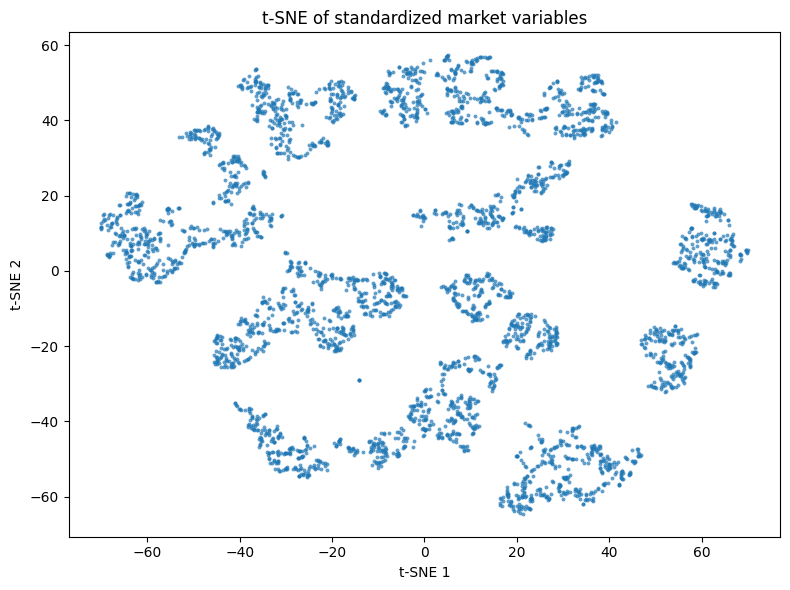

In [351]:
from sklearn.manifold import TSNE

# Fixed seed and PCA initialization make repeated runs reproducible.
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=1,
)
tsne_df = pd.DataFrame(
    tsne.fit_transform(subset_scaled_df),
    columns=["TSNE1", "TSNE2"],
    index=subset_scaled_df.index,
)

with plt.style.context("tableau-colorblind10"):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(
        tsne_df["TSNE1"], tsne_df["TSNE2"],
        color="tab:blue", s=8, alpha=0.7, linewidths=0,
    )
    ax.set(xlabel="t-SNE 1", ylabel="t-SNE 2",
           title="t-SNE of standardized market variables")
    plt.tight_layout()
    plt.show()


In [352]:
k_means_df = data_pca.copy()

Number of Clusters: 1 	Average Distortion: 2.7512140002918577
Number of Clusters: 2 	Average Distortion: 2.350974009347068
Number of Clusters: 3 	Average Distortion: 2.185019616190161
Number of Clusters: 4 	Average Distortion: 2.033914507285288
Number of Clusters: 5 	Average Distortion: 1.9580623653651055
Number of Clusters: 6 	Average Distortion: 1.8767217890731316
Number of Clusters: 7 	Average Distortion: 1.7067547478658296
Number of Clusters: 8 	Average Distortion: 1.614594877951014
Number of Clusters: 9 	Average Distortion: 1.5278757202172957
Number of Clusters: 10 	Average Distortion: 1.4959320056433183
Number of Clusters: 11 	Average Distortion: 1.4621619799258203
Number of Clusters: 12 	Average Distortion: 1.435841476697825
Number of Clusters: 13 	Average Distortion: 1.3833087785277778
Number of Clusters: 14 	Average Distortion: 1.3520591445062575


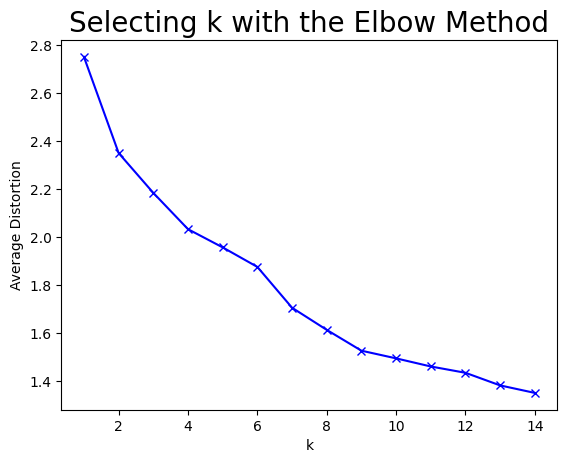

In [353]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
clusters = range(1, 15)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters = k, random_state = 1, n_init = "auto")
    model.fit(data_pca)
    prediction = model.predict(k_means_df)
    distortion = (
        sum(np.min(cdist(k_means_df, model.cluster_centers_, "euclidean"), axis = 1))
        / k_means_df.shape[0]
    )

    meanDistortions.append(distortion)

    print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average Distortion")
plt.title("Selecting k with the Elbow Method", fontsize = 20)
plt.show()

In [354]:
kmeans = KMeans(n_clusters = 3, random_state = 1, n_init = "auto")
kmeans.fit(k_means_df)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",1
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [355]:
# Creating a copy of the original data
df1 = df_transformed.copy()

# Adding K-Means cluster labels to the K-Means and original dataframes
k_means_df["KM_segments"] = kmeans.labels_
df1["KM_segments"] = kmeans.labels_

In [356]:
km_cluster_profile = df1.groupby("KM_segments").mean(numeric_only = True)

In [357]:
df1.head()

,sp500_log_return,breakeven_10y,real_yield_10y,slope_10y_2y,baa_10y_spread,vix,vix3m,vix_term_spread,sp500_gold_ratio,KM_segments
date,,,,,,,,,,
2011-10-06,0.018138,1.88,0.13,1.72,3.34,36.27,37.04,-0.77,0.705230,1
2011-10-07,-0.008197,1.94,0.16,1.80,3.32,36.20,37.31,-1.11,0.706920,1
2011-10-11,0.000544,1.95,0.23,1.86,3.32,32.86,34.06,-1.20,0.720335,1
2011-10-12,0.009747,1.98,0.26,1.95,3.33,31.26,32.97,-1.71,0.718046,1
2011-10-13,-0.002978,1.92,0.27,1.90,3.29,30.70,32.71,-2.01,0.721922,1


In [358]:
# Creating the "count_in_each_segment" feature in K-Means cluster profile

km_cluster_profile["count_in_each_segment"] = (
    df1.groupby("KM_segments")["sp500_log_return"].count().values
)

In [359]:
km_cluster_profile.style.highlight_max(color = "lightgreen", axis = 0)

,sp500_log_return,breakeven_10y,real_yield_10y,slope_10y_2y,baa_10y_spread,vix,vix3m,vix_term_spread,sp500_gold_ratio,count_in_each_segment
KM_segments,,,,,,,,,,
0,0.001235,2.211612,1.036835,0.229433,1.868688,17.288982,19.434987,-2.146005,2.114441,1905
1,-0.004093,1.736009,-0.143876,0.742156,2.745711,30.467867,31.008830,-0.540963,1.717254,436
2,0.000921,1.989406,0.160709,1.547588,2.682033,14.842155,16.988475,-2.146321,1.459156,1397


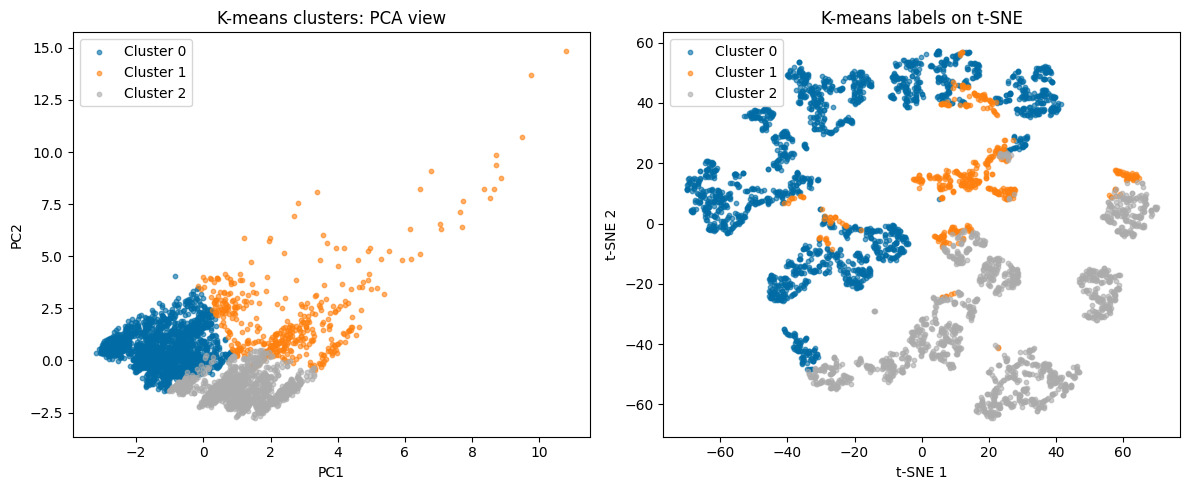

In [360]:
with plt.style.context("tableau-colorblind10"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for cluster in np.unique(kmeans.labels_):
        mask = kmeans.labels_ == cluster
        axes[0].scatter(data_pca.iloc[mask, 0], data_pca.iloc[mask, 1],
                        s=10, alpha=0.6, label=f"Cluster {cluster}")
        axes[1].scatter(tsne_df.iloc[mask, 0], tsne_df.iloc[mask, 1],
                        s=10, alpha=0.6, label=f"Cluster {cluster}")
    axes[0].set(xlabel="PC1", ylabel="PC2", title="K-means clusters: PCA view")
    axes[1].set(xlabel="t-SNE 1", ylabel="t-SNE 2", title="K-means labels on t-SNE")
    for ax in axes:
        ax.legend()
    plt.tight_layout()
    plt.show()


In [361]:
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score,
)

performance = []
for k in range(2, 11):
    candidate = KMeans(n_clusters=k, random_state=1, n_init="auto").fit(data_pca)
    labels = candidate.labels_
    performance.append([
        k, candidate.inertia_, silhouette_score(data_pca, labels),
        calinski_harabasz_score(data_pca, labels),
        davies_bouldin_score(data_pca, labels),
    ])

performance_df = pd.DataFrame(performance, columns=[
    "k", "Inertia", "Silhouette", "Calinski_Harabasz", "Davies_Bouldin",
]).set_index("k")
performance_df.round(3)

,Inertia,Silhouette,Calinski_Harabasz,Davies_Bouldin
k,,,,
2,25844.666,0.263,1127.162,1.625
3,21613.124,0.262,1039.365,1.417
4,18688.459,0.294,995.918,1.306
5,17327.218,0.241,878.720,1.410
6,15633.605,0.244,859.791,1.439
7,13156.217,0.296,968.268,1.243
8,12184.146,0.291,938.430,1.206
9,11266.264,0.290,925.763,1.203
10,10841.288,0.287,871.166,1.255


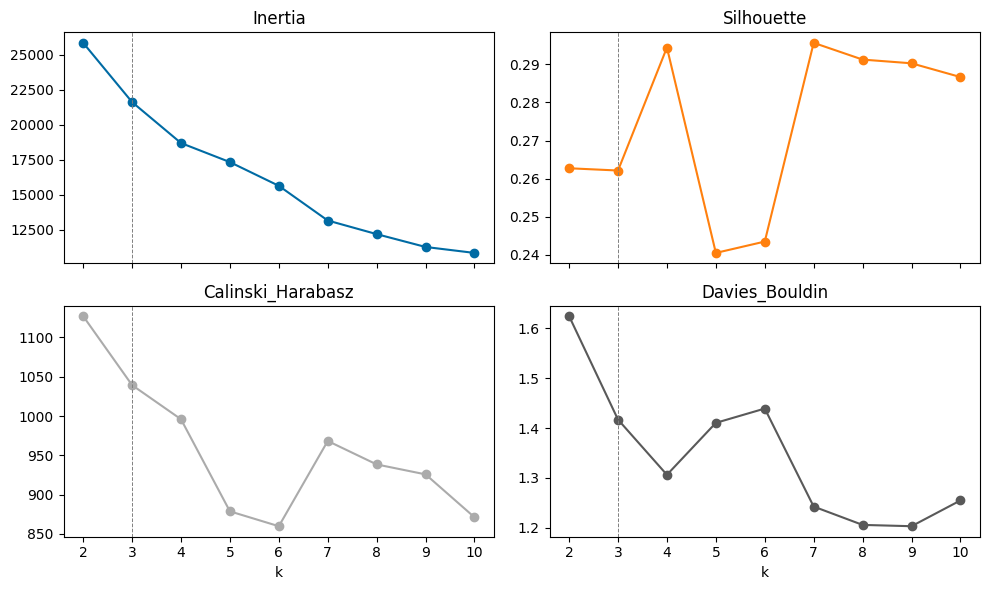

In [362]:
axes = performance_df.plot(subplots=True, layout=(2, 2), figsize=(10, 6),
                           sharex=True, legend=False, marker="o")
for ax, metric in zip(axes.flat, performance_df.columns):
    ax.set_title(metric)
    ax.axvline(kmeans.n_clusters, color="grey", linestyle="--", linewidth=0.7)
plt.tight_layout()
plt.show()

In [363]:
from scipy.cluster.hierarchy import linkage, cophenet, dendrogram
from scipy.spatial.distance import pdist

pairwise_distances = pdist(data_pca, metric="euclidean")
ward_linkage = linkage(pairwise_distances, method="ward")
cophenetic_correlation, _ = cophenet(ward_linkage, pairwise_distances)
cophenetic_correlation

np.float64(0.4687127889997122)

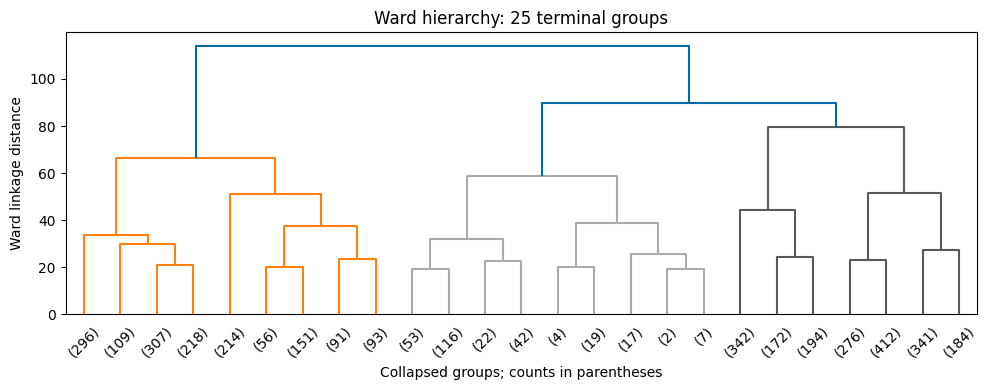

In [364]:
from scipy.cluster.hierarchy import dendrogram
plt.figure(figsize=(10, 4))
dendrogram(ward_linkage, truncate_mode="lastp", p=25, show_leaf_counts=True)
plt.title("Ward hierarchy: 25 terminal groups")
plt.xlabel("Collapsed groups; counts in parentheses")
plt.ylabel("Ward linkage distance")
plt.tight_layout()
plt.show()

## Entropy Pooling and three-state resampling

Adapt [Fortitudo Section 3.2.1](../chapter3_2_1.ipynb) by replacing low/mid/high volatility bands with K-means cluster codes **0, 1, 2**. These codes are categorical, not numerical views or an ordering of risk.

Keep the reference interface: `st_df`, `states_vector`, exponential-decay `p_exp`, one posterior `q0`/`q1`/`q2`, `states_prob` with shape `(T, 3)`, and resampled observation indices `sim0`/`sim1`/`sim2`. The multivariate extension uses cluster means and population variances (`ddof=0`) of all nine standardized features, including the S&P 500/gold ratio. Gold levels are absent.

**Default matches the reference:** means are equality views; second moments are upper-bound views, `G @ q <= variance + mean**2`. With the mean fixed, this caps variance rather than matching it exactly. Set `VARIANCE_MODE = "equal"` for exact second-moment/variance matching. There are no separate covariance views.

Clustering and EP calibration use the full sample, including contemporaneous equity returns. This is a descriptive conditional resampling experiment; it is not a next-day forecast or a backtest. Cluster labels are specific to this fitted model. The only simulated stationary transformation here is the S&P 500 log return; macro and ratio levels are state variables, not additive increments. The model-induced state transitions below follow the reference's sampled-row update and are not estimated historical next-day transitions.

Adapted code: pcrm-book, copyright (C) 2025 Anton Vorobets, GPL-3.0-or-later. Original license notice is retained at the end of this notebook. [Fortitudo API and constraint convention](https://os.fortitudo.tech/documentation#entropy-pooling).

In [365]:
import fortitudo.tech as ft
from scipy.linalg import qr
from IPython.display import display

NUM_STATES = 3
VARIANCE_MODE = "upper_bound"  # Fortitudo default; "equal" matches variances exactly
VIEW_COLUMNS = list(subset_scaled_df.columns)
S = 10_000
H = 21
SEED = 0
EP_TOL = 1e-5  # absolute residual tolerance in standardized coordinates

if kmeans.n_clusters != NUM_STATES:
    raise ValueError("Fit the three-cluster K-means cell before running EP.")
if VARIANCE_MODE not in {"upper_bound", "equal"}:
    raise ValueError("VARIANCE_MODE must be 'upper_bound' or 'equal'.")

st_df = df_transformed[["sp500_log_return"]].copy()
states_vector = df1["KM_segments"].to_numpy(dtype=int)
ep_features = subset_scaled_df[VIEW_COLUMNS].copy()
T_tilde = len(st_df)
assert st_df.index.equals(ep_features.index) and st_df.index.equals(df1.index)
assert np.array_equal(np.unique(states_vector), np.arange(NUM_STATES))
assert "sp500_gold_ratio" in ep_features and "gold" not in ep_features

# Same exponential-decay prior and half-life as Section 3.2.1.
HALF_LIFE = T_tilde / 2
p_exp = ft.exp_decay_probs(st_df, half_life=HALF_LIFE)
p_exp = p_exp / p_exp.sum()
assert p_exp.shape == (T_tilde, 1) and (p_exp > 0).all()

cluster_means = ep_features.groupby(states_vector).mean()
cluster_variances = ep_features.groupby(states_vector).var(ddof=0)
cluster_counts = pd.Series(states_vector).value_counts().sort_index()
display(cluster_means)
display(cluster_variances)

,sp500_log_return,breakeven_10y,real_yield_10y,slope_10y_2y,baa_10y_spread,vix,vix3m,vix_term_spread,sp500_gold_ratio
0,0.069633,0.397703,0.484349,-0.683270,-0.751496,-0.094533,-0.073946,-0.112834,0.638502
1,-0.432596,-0.967803,-0.745090,-0.049119,0.870787,1.906066,1.890614,0.855145,-0.232312
2,0.040057,-0.240274,-0.427935,0.947062,0.752997,-0.465970,-0.489220,-0.113024,-0.798180


,sp500_log_return,breakeven_10y,real_yield_10y,slope_10y_2y,baa_10y_spread,vix,vix3m,vix_term_spread,sp500_gold_ratio
0,0.697700,0.549324,1.144824,0.467588,0.217728,0.392301,0.445351,0.517354,0.340231
1,3.826309,1.882230,0.685809,0.425292,1.014992,1.814724,1.398568,4.329889,0.797025
2,0.463521,0.773478,0.224279,0.371079,0.488288,0.211216,0.269588,0.360540,0.753166


### Encode the moment views and solve EP

Use `A = [ones; features.T]`, `b = [1; cluster_means]`, `G = features.T**2` and `h = cluster_variances + cluster_means**2`, extending the scalar reference to all features. Standardization improves numerical conditioning and gives equivalent raw-unit mean/variance views.

VIX, VIX3M and their spread make one mean constraint redundant. QR selects independent equality rows for the solver; every original mean and variance constraint is still validated after solving. Posteriors are normalized and the cell stops if the constraints fail the stated tolerance.

In [366]:
X = ep_features.to_numpy(dtype=float)
A = np.vstack((np.ones((1, T_tilde)), X.T))
G = X.T ** 2


def independent_equality_rows(matrix):
    # Pivot rows via columns of the transpose, retaining an independent system.
    _, _, pivots = qr(matrix.T, mode="economic", pivoting=True)
    return np.sort(pivots[:np.linalg.matrix_rank(matrix)])


def solve_cluster_ep(variance_mode):
    if variance_mode not in {"upper_bound", "equal"}:
        raise ValueError("Unknown variance mode.")
    equality_matrix = A if variance_mode == "upper_bound" else np.vstack((A, G))
    equality_rows = independent_equality_rows(equality_matrix)
    posteriors, constraint_rows = [], []
    for state in range(NUM_STATES):
        mu = cluster_means.loc[state].to_numpy()
        var = cluster_variances.loc[state].to_numpy()
        b = np.r_[1.0, mu][:, np.newaxis]
        h = (var + mu ** 2)[:, np.newaxis]
        equality_targets = b if variance_mode == "upper_bound" else np.vstack((b, h))
        if variance_mode == "upper_bound":
            q = ft.entropy_pooling(
                p_exp, equality_matrix[equality_rows], equality_targets[equality_rows], G, h
            )
        else:
            q = ft.entropy_pooling(
                p_exp, equality_matrix[equality_rows], equality_targets[equality_rows]
            )
        if not np.isfinite(q).all() or (q < 0).any() or q.sum() <= 0:
            raise RuntimeError(f"Invalid EP probabilities for cluster {state}.")
        q = q / q.sum()
        mean_error = float(np.max(np.abs(A @ q - b)))
        second_moment_residual = G @ q - h
        variance_error = float(
            np.max(second_moment_residual) if variance_mode == "upper_bound"
            else np.max(np.abs(second_moment_residual))
        )
        if mean_error > EP_TOL or variance_error > EP_TOL:
            raise RuntimeError(
                f"Cluster {state}: EP constraints failed: mean={mean_error:.2e}, "
                f"second moment={variance_error:.2e}. No simulation was produced."
            )
        posteriors.append(q)
        constraint_rows.append({
            "state": state,
            "historical_count": int(cluster_counts.loc[state]),
            "max_mean_error_scaled": mean_error,
            "max_second_moment_residual_scaled": variance_error,
            "effective_scenarios": float(1 / np.sum(q ** 2)),
        })
    return np.hstack(posteriors), pd.DataFrame(constraint_rows).set_index("state")


states_prob, ep_diagnostics = solve_cluster_ep(VARIANCE_MODE)
q0, q1, q2 = [states_prob[:, [state]] for state in range(NUM_STATES)]
assert states_prob.shape == (T_tilde, NUM_STATES)
assert np.allclose(states_prob.sum(axis=0), 1.0)
display(ep_diagnostics)

,historical_count,max_mean_error_scaled,max_second_moment_residual_scaled,effective_scenarios
state,,,,
0,1905,5.674897e-07,1.845528e-07,1965.630580
1,436,1.791184e-06,3.169593e-06,402.963132
2,1397,8.070797e-07,1.022582e-06,1399.332376


target_mean  posterior_mean  target_variance  \
state feature                                                          
0     sp500_log_return     0.001235        0.001235         0.000079   
      breakeven_10y        2.211612        2.211611         0.066639   
      real_yield_10y       1.036835        1.036834         1.055875   
      slope_10y_2y         0.229433        0.229433         0.305664   
      baa_10y_spread       1.868688        1.868688         0.063633   
      vix                 17.288982       17.288982        17.023815   
      vix3m               19.434987       19.434987        15.457059   
      vix_term_spread     -2.146005       -2.146005         1.422424   
      sp500_gold_ratio     2.114441        2.114441         0.070780   
1     sp500_log_return    -0.004093       -0.004093         0.000431   
      breakeven_10y        1.736009        1.736009         0.228335   
      real_yield_10y      -0.143876       -0.143876         0.632524   
      slope_10y_2y         0.742156        0.742156         0.278015   
      baa_10y_spread       2.745711        2.745711         0.296641   
      vix                 30.467867       30.467877        78.749489   
      vix3m               31.008830       31.008841        48.540975   
      vix_term_spread     -0.540963       -0.540964        11.904676   
      sp500_gold_ratio     1.717254        1.717254         0.165810   
2     sp500_log_return     0.000921        0.000921         0.000052   
      breakeven_10y        1.989406        1.989406         0.093832   
      real_yield_10y       0.160709        0.160709         0.206853   
      slope_10y_2y         1.547588        1.547587         0.242575   
      baa_10y_spread       2.682033        2.682033         0.142707   
      vix                 14.842155       14.842155         9.165662   
      vix3m               16.988475       16.988475         9.356767   
      vix_term_spread     -2.146321       -2.146320         0.991274   
      sp500_gold_ratio     1.459156        1.459156         0.156686   

                        posterior_variance  
state feature                               
0     sp500_log_return            0.000077  
      breakeven_10y               0.066639  
      real_yield_10y              1.055875  
      slope_10y_2y                0.305663  
      baa_10y_spread              0.063633  
      vix                        17.023823  
      vix3m                      15.457062  
      vix_term_spread             1.422424  
      sp500_gold_ratio            0.070780  
1     sp500_log_return            0.000410  
      breakeven_10y               0.228335  
      real_yield_10y              0.632525  
      slope_10y_2y                0.278015  
      baa_10y_spread              0.296642  
      vix                        78.749245  
      vix3m                      48.540850  
      vix_term_spread            11.076054  
      sp500_gold_ratio            0.165810  
2     sp500_log_return            0.000051  
      breakeven_10y               0.093831  
      real_yield_10y              0.206854  
      slope_10y_2y                0.242577  
      baa_10y_spread              0.142707  
      vix                         9.165644  
      vix3m                       8.934302  
      vix_term_spread             0.987443  
      sp500_gold_ratio            0.156686

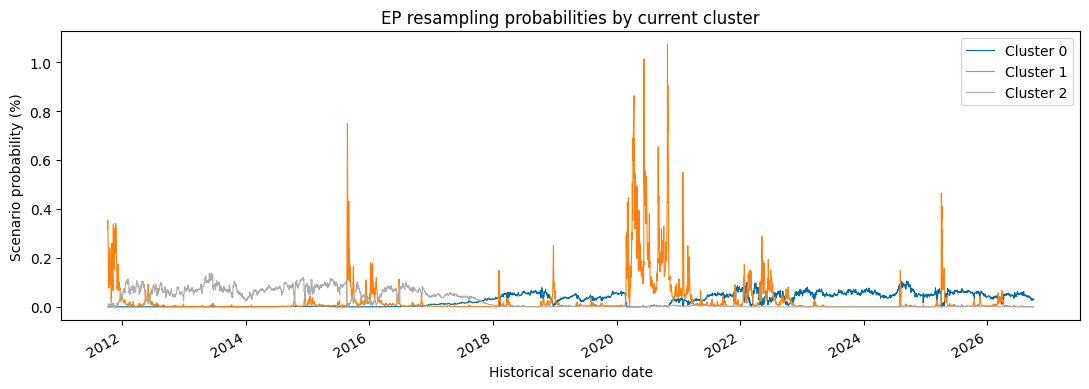

In [367]:
# Compare target and posterior moments in the original feature units.
feature_location = pd.Series(scaler.mean_, index=subset.columns).loc[VIEW_COLUMNS]
feature_scale = pd.Series(scaler.scale_, index=subset.columns).loc[VIEW_COLUMNS]
moment_rows = []
for state in range(NUM_STATES):
    q = states_prob[:, state]
    posterior_mu = q @ X
    posterior_var = q @ ((X - posterior_mu) ** 2)
    for j, column in enumerate(VIEW_COLUMNS):
        scale, location = feature_scale[column], feature_location[column]
        moment_rows.append({
            "state": state, "feature": column,
            "target_mean": cluster_means.loc[state, column] * scale + location,
            "posterior_mean": posterior_mu[j] * scale + location,
            "target_variance": cluster_variances.loc[state, column] * scale ** 2,
            "posterior_variance": posterior_var[j] * scale ** 2,
        })
moment_comparison = pd.DataFrame(moment_rows).set_index(["state", "feature"])
display(moment_comparison)

probability_df = pd.DataFrame(
    states_prob, index=st_df.index, columns=[f"Cluster {j}" for j in range(NUM_STATES)]
)
ax = (100 * probability_df).plot(figsize=(11, 4), linewidth=0.8)
ax.set(title="EP resampling probabilities by current cluster",
       xlabel="Historical scenario date", ylabel="Scenario probability (%)")
plt.tight_layout()
plt.show()

### State-dependent simulation

Keep the reference's update: sample a historical row using the current state's EP vector, then set the next state to that row's cluster label. All features from a sampled row remain jointly associated. `resampling` returns observation indices with shape `(S, H)`; only equity log returns are accumulated into equity paths. Each horizon step is interpreted as one modeled trading day.

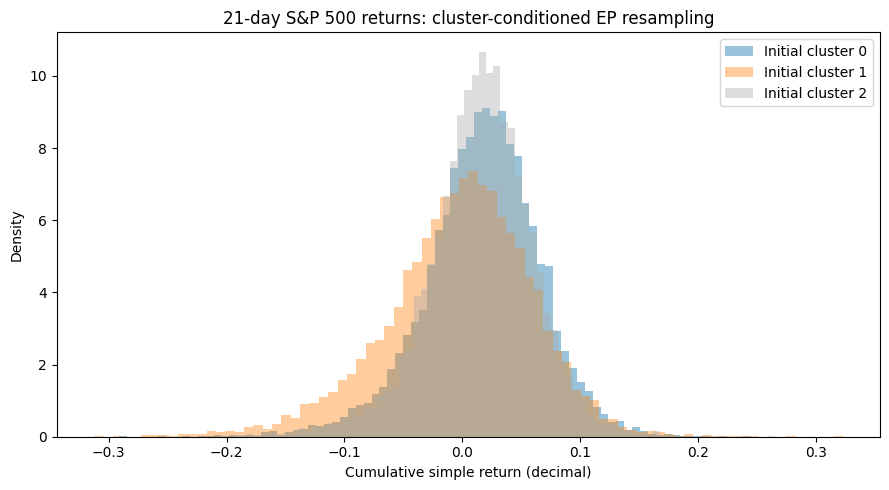

,mean_return,std_return,p05,median,p95,probability_of_loss
initial_state,,,,,,
0,0.016821,0.049366,-0.066957,0.018958,0.092069,0.3333
1,-0.003003,0.062432,-0.112745,0.001241,0.089538,0.4911
2,0.015363,0.044643,-0.060257,0.017241,0.082935,0.3274


In [368]:
# Adapted from Section 3.2.1; vectorize across paths while keeping its state update.
def resampling(S, H, initial_state, states_prob, states_vector, rng=None):
    if S < 1 or H < 1:
        raise ValueError("S and H must be positive.")
    probabilities = np.asarray(states_prob, dtype=float)
    labels = np.asarray(states_vector, dtype=int)
    if probabilities.shape != (len(labels), NUM_STATES):
        raise ValueError("Probability rows and state labels must align.")
    if not np.isfinite(probabilities).all() or (probabilities < 0).any():
        raise ValueError("Probabilities must be finite and nonnegative.")
    if not np.allclose(probabilities.sum(axis=0), 1):
        raise ValueError("Each state's probabilities must sum to one.")
    if initial_state not in range(NUM_STATES) or not np.isin(labels, range(NUM_STATES)).all():
        raise ValueError("States must be encoded as 0, 1, 2.")
    if rng is None:
        rng = np.random.default_rng(SEED)
    sim = np.empty((S, H), dtype=int)
    current_state = np.full(S, initial_state, dtype=int)
    t = np.arange(len(labels))
    for h in range(H):
        # Use all states at the beginning of this step, before updating any path.
        for state in range(NUM_STATES):
            mask = current_state == state
            sim[mask, h] = rng.choice(t, size=int(mask.sum()), p=probabilities[:, state])
        current_state = labels[sim[:, h]]
    return sim


rng = np.random.default_rng(SEED)
sim0 = resampling(S, H, 0, states_prob, states_vector, rng)
sim1 = resampling(S, H, 1, states_prob, states_vector, rng)
sim2 = resampling(S, H, 2, states_prob, states_vector, rng)
simulations = {0: sim0, 1: sim1, 2: sim2}

equity_log_returns = st_df["sp500_log_return"].to_numpy()
return0 = np.expm1(np.cumsum(equity_log_returns[sim0], axis=1))
return1 = np.expm1(np.cumsum(equity_log_returns[sim1], axis=1))
return2 = np.expm1(np.cumsum(equity_log_returns[sim2], axis=1))
return_paths = {0: return0, 1: return1, 2: return2}

summary_rows = []
fig, ax = plt.subplots(figsize=(9, 5))
for state, paths in return_paths.items():
    terminal = paths[:, -1]
    quantiles = np.quantile(terminal, [0.05, 0.5, 0.95])
    summary_rows.append({
        "initial_state": state,
        "mean_return": terminal.mean(), "std_return": terminal.std(ddof=0),
        "p05": quantiles[0], "median": quantiles[1], "p95": quantiles[2],
        "probability_of_loss": np.mean(terminal < 0),
    })
    ax.hist(terminal, bins=80, density=True, alpha=0.4, label=f"Initial cluster {state}")
ax.set(title=f"{H}-day S&P 500 returns: cluster-conditioned EP resampling",
       xlabel="Cumulative simple return (decimal)", ylabel="Density")
ax.legend()
plt.tight_layout()
plt.show()
simulation_summary = pd.DataFrame(summary_rows).set_index("initial_state")
display(simulation_summary)

In [369]:
# Model-induced transitions, with rows=current state and columns=next state.
transition_matrix = np.array([
    [states_prob[states_vector == next_state, current_state].sum()
     for next_state in range(NUM_STATES)]
    for current_state in range(NUM_STATES)
])
assert np.allclose(transition_matrix.sum(axis=1), 1)
transition_df = pd.DataFrame(
    transition_matrix,
    index=pd.Index(range(NUM_STATES), name="current_state"),
    columns=pd.Index(range(NUM_STATES), name="next_state"),
)
display(transition_df.round(4))

next_state,0,1,2
current_state,,,
0,0.9310,0.0278,0.0411
1,0.1419,0.7629,0.0952
2,0.0365,0.0204,0.9431


### Save the handoff to the Fortitudo pipeline

All arrays use the same row order, recorded in `ep_scenarios.csv`. The compressed bundle retains the reference variable names, scaled EP features, prior, posteriors, transitions, and simulated row indices and equity returns. `ep_metadata.json` records the configuration and feature scaling. Saved diagnostics allow the moment views to be reviewed without rerunning the simulation. Re-run the notebook after changing the cluster model, feature set or variance mode.

In [370]:
import json

EP_DIR = Path("data") / "ep"
EP_DIR.mkdir(parents=True, exist_ok=True)
ep_scenarios = df_transformed.copy()
ep_scenarios["state"] = states_vector
ep_scenarios["prior_probability"] = p_exp[:, 0]
for state in range(NUM_STATES):
    ep_scenarios[f"q{state}"] = states_prob[:, state]
ep_scenarios.to_csv(EP_DIR / "ep_scenarios.csv", index_label="date")
ep_diagnostics.to_csv(EP_DIR / "ep_diagnostics.csv")
moment_comparison.to_csv(EP_DIR / "moment_comparison.csv")
simulation_summary.to_csv(EP_DIR / "simulation_summary.csv")
transition_df.to_csv(EP_DIR / "transition_matrix.csv")
np.savez_compressed(
    EP_DIR / "cluster_ep_simulation.npz",
    st_df=st_df.to_numpy(), st_columns=np.array(st_df.columns, dtype=str),
    ep_features=X, view_columns=np.array(VIEW_COLUMNS, dtype=str),
    dates=st_df.index.to_numpy(dtype="datetime64[ns]"),
    states_vector=states_vector, p_exp=p_exp, states_prob=states_prob,
    q0=q0, q1=q1, q2=q2, transition_matrix=transition_matrix,
    sim0=sim0, sim1=sim1, sim2=sim2,
    return0=return0, return1=return1, return2=return2,
)
ep_metadata = {
    "reference": "../chapter3_2_1.ipynb",
    "num_states": NUM_STATES,
    "state_encoding": "0, 1, 2; unordered K-means labels",
    "view_columns": VIEW_COLUMNS,
    "stationary_columns": list(st_df.columns),
    "variance_mode": VARIANCE_MODE,
    "mean_constraints": "equalities",
    "variance_constraints": "upper bounds" if VARIANCE_MODE == "upper_bound" else "equalities",
    "moment_ddof": 0,
    "half_life_observations": HALF_LIFE,
    "simulated_paths_per_initial_state": S, "horizon": H, "seed": SEED,
    "ep_tolerance_standardized": EP_TOL,
    "kmeans_random_state": kmeans.random_state, "kmeans_n_init": kmeans.n_init,
    "first_scenario_date": st_df.index.min().date().isoformat(),
    "last_scenario_date": st_df.index.max().date().isoformat(),
    "num_scenarios": T_tilde,
    "feature_mean": feature_location.to_dict(), "feature_scale": feature_scale.to_dict(),
    "calibration": "full-sample contemporaneous cluster-conditioned descriptive resampling",
    "transition_rule": "next state is the sampled historical row's cluster label",
}
(EP_DIR / "ep_metadata.json").write_text(json.dumps(ep_metadata, indent=2), encoding="utf-8")
print(f"Saved Fortitudo-compatible EP handoff to {EP_DIR.resolve()}")

Saved Fortitudo-compatible EP handoff to /Users/lajosgalambos/Desktop/Quantitative_Investment_Management 2/Chapters/clustering-entropy-pooling/data/ep


In [371]:
# pcrm-book - Next generation investment analysis.
# Copyright (C) 2025 Anton Vorobets.

# This program is free software: you can redistribute it and/or modify
# it under the terms of the GNU General Public License as published by
# the Free Software Foundation, either version 3 of the License, or
# (at your option) any later version.

# This program is distributed in the hope that it will be useful,
# but WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the
# GNU General Public License for more details.

# You should have received a copy of the GNU General Public License
# along with this program.  If not, see <https://www.gnu.org/licenses/>.